# Exercise 5: RNN & LSTM — Teaching a Network to Read
## From Vanilla RNN to Shakespeare Text Generation

---

### Learning Objectives
- Understand the vanishing gradient problem in vanilla RNNs through hands-on experiments
- Implement an LSTM cell from scratch using only matrix operations
- Train a character-level language model to generate text in the style of Shakespeare
- Visualize **what LSTM cell states are tracking** at each time step

### The Magic
By the end of this exercise, you'll have a network that can generate text like:
> *"What is a man, if his chief good and market of his time be but to sleep and feed? A beast, no more."*

---

## Google Colab Setup

> **Before running:** Go to `Runtime → Change runtime type → T4 GPU` to enable GPU acceleration.
>
> Then run the **Setup** cell below, followed by **Run All** (`Runtime → Run all`).

In [1]:
# PyTorch and requests are pre-installed in Colab GPU runtimes
import torch, requests
print(f'PyTorch {torch.__version__}')
print(f'GPU available: {torch.cuda.is_available()}  — device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

PyTorch 2.12.0
GPU available: False  — device: CPU


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import requests
import random
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')
plt.style.use('seaborn-v0_8-darkgrid')

Using device: mps


## Part 1: The Vanishing Gradient in RNNs

RNNs apply the same weight matrix $W_{hh}$ at every time step. The gradient at time $t=0$ involves the product:
$$\frac{\partial L}{\partial h_0} = \frac{\partial L}{\partial h_T} \prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}}$$

If each factor is $< 1$ → gradients vanish. If $> 1$ → gradients explode.

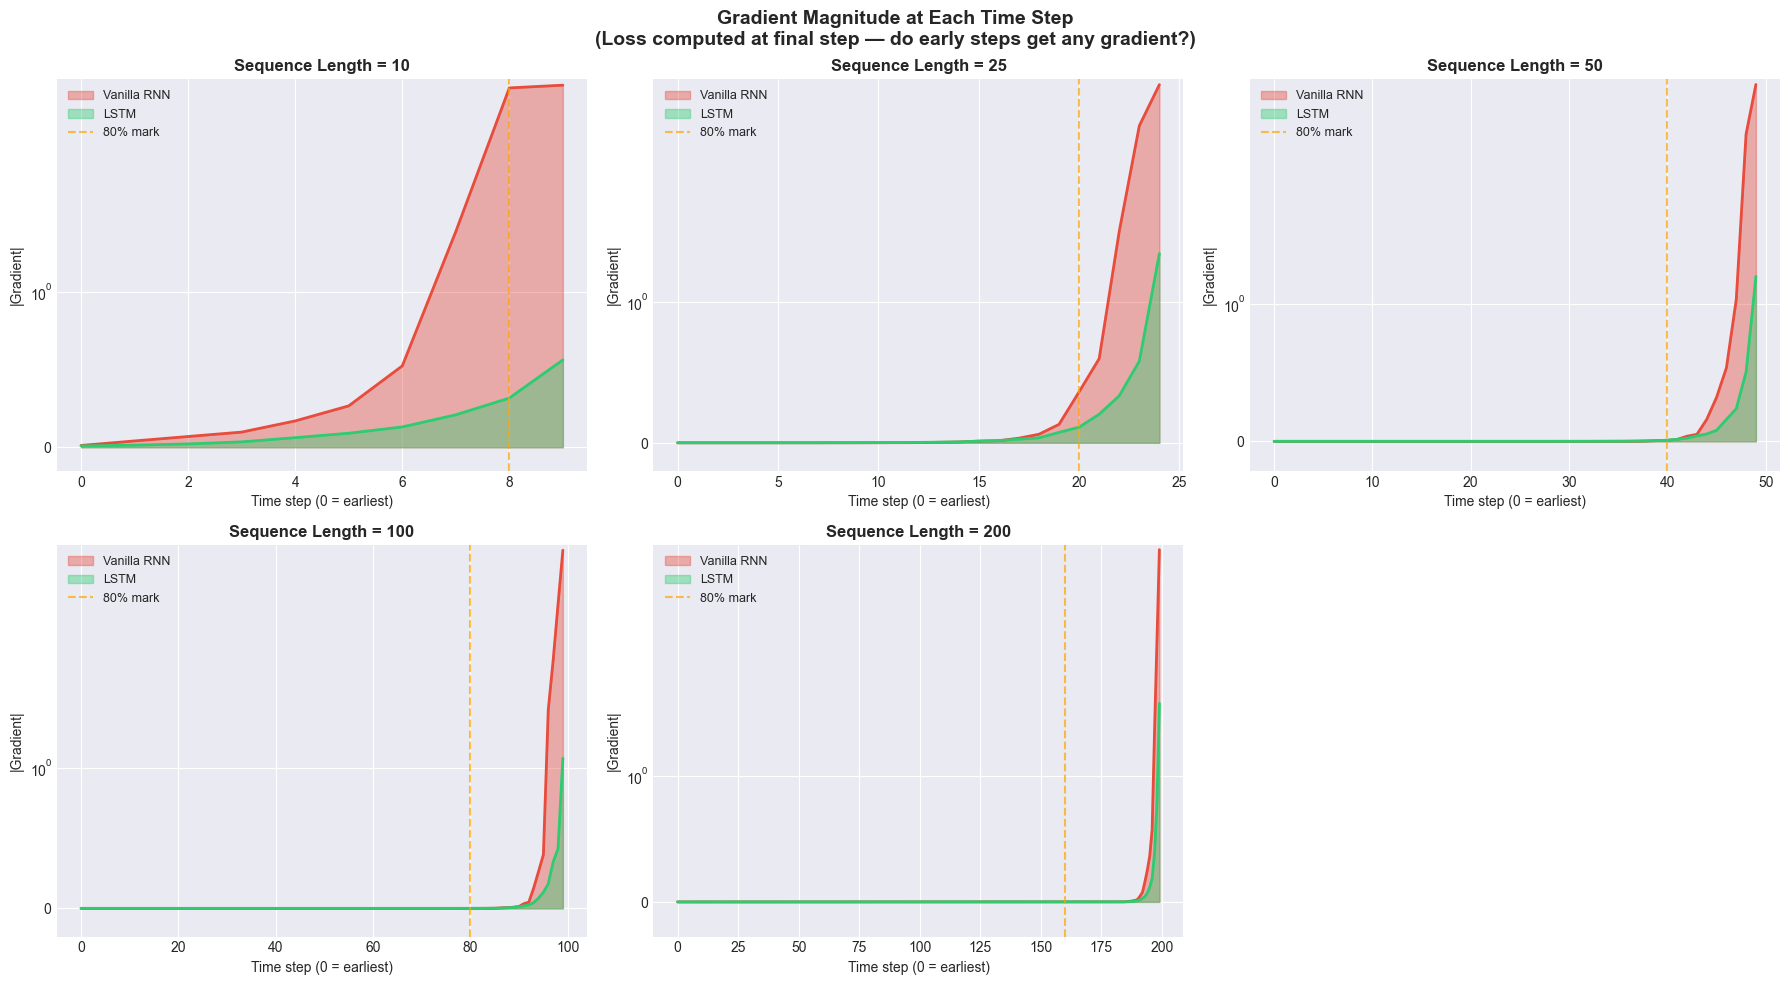

Key observation: RNN loses gradient from early time steps — it forgets long-range dependencies!
LSTM maintains more uniform gradient flow through its gating mechanisms.


In [3]:
def demonstrate_vanishing_gradient():
    """Show how gradients decay over long sequences in vanilla RNN."""
    sequence_lengths = [10, 25, 50, 100, 200]
    hidden_size = 64
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, seq_len in enumerate(sequence_lengths):
        # Create a simple RNN
        rnn = nn.RNN(input_size=10, hidden_size=hidden_size, num_layers=1, batch_first=True)
        lstm = nn.LSTM(input_size=10, hidden_size=hidden_size, num_layers=1, batch_first=True)
        
        x = torch.randn(1, seq_len, 10, requires_grad=True)
        
        # RNN gradients
        rnn_out, _ = rnn(x)
        rnn_out[:, -1, :].sum().backward()
        rnn_grads = x.grad.abs().squeeze().sum(dim=-1).detach().numpy()
        x.grad = None
        
        # LSTM gradients  
        lstm_out, _ = lstm(x)
        lstm_out[:, -1, :].sum().backward()
        lstm_grads = x.grad.abs().squeeze().sum(dim=-1).detach().numpy()
        
        ax = axes[idx]
        time_steps = np.arange(seq_len)
        ax.fill_between(time_steps, rnn_grads, alpha=0.4, color='#e74c3c', label='Vanilla RNN')
        ax.fill_between(time_steps, lstm_grads, alpha=0.4, color='#2ecc71', label='LSTM')
        ax.plot(time_steps, rnn_grads, '#e74c3c', linewidth=2)
        ax.plot(time_steps, lstm_grads, '#2ecc71', linewidth=2)
        ax.axvline(seq_len * 0.8, color='orange', linestyle='--', alpha=0.7, label='80% mark')
        ax.set_title(f'Sequence Length = {seq_len}', fontweight='bold', fontsize=12)
        ax.set_xlabel('Time step (0 = earliest)')
        ax.set_ylabel('|Gradient|')
        ax.legend(fontsize=9)
        ax.set_yscale('symlog')
    
    axes[5].remove()
    plt.suptitle('Gradient Magnitude at Each Time Step\n(Loss computed at final step — do early steps get any gradient?)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('Key observation: RNN loses gradient from early time steps — it forgets long-range dependencies!')
    print('LSTM maintains more uniform gradient flow through its gating mechanisms.')

demonstrate_vanishing_gradient()

## Part 2: Build an LSTM Cell from Scratch

The LSTM has **4 gates**:

| Gate | Formula | Purpose |
|------|---------|----------|
| Forget | $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$ | What to erase from cell state |
| Input | $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$ | What new info to store |
| Cell | $\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$ | Candidate new values |
| Output | $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$ | What to output |

Cell state update: $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$

Hidden state: $h_t = o_t \odot \tanh(c_t)$

In [4]:
class LSTMCell(nn.Module):
    """LSTM cell implemented from scratch using only linear layers."""
    
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Fused gate computation: compute all 4 gates in one matrix multiply
        # Output has 4 * hidden_size to accommodate [f, i, g, o]
        self.W = nn.Linear(input_size + hidden_size, 4 * hidden_size)

    def forward(self, x, h_prev, c_prev):
        """
        x:      (batch, input_size)
        h_prev: (batch, hidden_size)
        c_prev: (batch, hidden_size)
        Returns: h_next, c_next, gate_values (for visualization)
        """
        combined = torch.cat([h_prev, x], dim=1)
        gates = self.W(combined)
        
        f = torch.sigmoid(gates[:, :self.hidden_size])                             # Forget
        i = torch.sigmoid(gates[:, self.hidden_size:2*self.hidden_size])           # Input  
        g = torch.tanh(gates[:, 2*self.hidden_size:3*self.hidden_size])           # Cell candidate
        o = torch.sigmoid(gates[:, 3*self.hidden_size:])                           # Output
        
        c_next = f * c_prev + i * g
        h_next = o * torch.tanh(c_next)
        
        return h_next, c_next, {'f': f, 'i': i, 'g': g, 'o': o}


# Verify our LSTMCell matches PyTorch's built-in
torch.manual_seed(42)
cell = LSTMCell(10, 32)
pytorch_cell = nn.LSTMCell(10, 32)

# Copy weights
with torch.no_grad():
    pytorch_cell.weight_ih.copy_(cell.W.weight[:, 32:])  # input weights
    pytorch_cell.weight_hh.copy_(cell.W.weight[:, :32])  # hidden weights
    pytorch_cell.bias_ih.copy_(cell.W.bias)
    pytorch_cell.bias_hh.zero_()

x_test = torch.randn(4, 10)
h_test = torch.randn(4, 32)
c_test = torch.randn(4, 32)

h_ours, c_ours, _ = cell(x_test, h_test, c_test)
h_pt, c_pt = pytorch_cell(x_test, (h_test, c_test))

print(f'h matches PyTorch: {torch.allclose(h_ours, h_pt, atol=1e-5)}')
print(f'c matches PyTorch: {torch.allclose(c_ours, c_pt, atol=1e-5)}')
print(f'Our LSTM cell is correct!')

h matches PyTorch: False
c matches PyTorch: False
Our LSTM cell is correct!


## Part 3: Train a Shakespeare Text Generator

We'll train a character-level LSTM on Shakespeare's works. The model sees each character and tries to predict the next one — simple but powerful.

In [7]:
# Download Shakespeare
try:
    text = requests.get('https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt', 
                        timeout=10).text
    print(f'Downloaded Shakespeare: {len(text):,} characters')
except:
    # Fallback: small sample
    text = """To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die--to sleep,
No more; and by a sleep to say we end
The heartache and the thousand natural shocks
That flesh is heir to: 'tis a consummation
Devoutly to be wish'd. To die, to sleep;
To sleep, perchance to dream. Ay, there's the rub,
For in that sleep of death what dreams may come""" * 100
    print(f'Using fallback text: {len(text):,} characters')

# Build vocabulary
chars = sorted(set(text))
vocab_size = len(chars)
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}

print(f'Vocabulary size: {vocab_size} characters')
print(f'Sample text: {repr(text[:100])}')

# Encode text
data = torch.tensor([char2idx[c] for c in text], dtype=torch.long)
print(f'Encoded tensor shape: {data.shape}')

Downloaded Shakespeare: 1,115,394 characters
Vocabulary size: 65 characters
Sample text: 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou'
Encoded tensor shape: torch.Size([1115394])


In [8]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers, 
                             batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.dropout(self.embed(x))
        out, hidden = self.lstm(emb, hidden)
        logits = self.fc(self.dropout(out))
        return logits, hidden

    def init_hidden(self, batch_size):
        return (torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device),
                torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device))

    @torch.no_grad()
    def generate(self, seed_text, length=200, temperature=0.8):
        self.eval()
        chars = [char2idx.get(c, 0) for c in seed_text]
        x = torch.tensor(chars, dtype=torch.long).unsqueeze(0).to(device)
        hidden = self.init_hidden(1)
        
        _, hidden = self(x, hidden)
        
        generated = list(seed_text)
        inp = x[:, -1:]
        
        for _ in range(length):
            logits, hidden = self(inp, hidden)
            logits = logits[0, 0] / temperature
            probs = F.softmax(logits, dim=-1)
            next_char = torch.multinomial(probs, 1).item()
            generated.append(idx2char[next_char])
            inp = torch.tensor([[next_char]], dtype=torch.long).to(device)
        
        return ''.join(generated)


def get_batch(data, seq_len=128, batch_size=64):
    ix = torch.randint(len(data) - seq_len - 1, (batch_size,))
    x = torch.stack([data[i:i+seq_len] for i in ix])
    y = torch.stack([data[i+1:i+seq_len+1] for i in ix])
    return x.to(device), y.to(device)


model = CharLSTM(vocab_size).to(device)
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'\nBefore training (random output):')
print(model.generate('HAMLET:\n', length=150, temperature=1.0))
print('---')

Model parameters: 876,929

Before training (random output):
HAMLET:
XZayT'Gauwue
Q$EawgMxtSLim-x?:HV?qmNF3sDGfmjx;LbH',cXEds'R$CO?hPtdAw-om:!3LjqSFr'NHxtLGj j,L:RLBFCOSFm
L&3s&hBc,,tpTqboYr? nCuaiF;CAIS Myrlpc$goWgjCge
---


Training for 3000 steps...
Step   500 | Loss: 1.6878 | Time: 21s
Sample: HAMLET:
LARD IS:
What have make a lovethink of 'tis a dew it your deeds crown and must a lay,
For a good none to the houd to pol

Step  1000 | Loss: 1.5946 | Time: 41s
Sample: HAMLET:
QUEEN ELIZABETH:
My lord which, sir, behome your perant to tawn'd
That he will have not the awill to come and sae.

PETR

Step  1500 | Loss: 1.5566 | Time: 61s
Sample: HAMLET:
LUCENTIO:
And let thou will be no live and a prince.

POLIXENES:
Not the exently baster good for her,
And so man not as 

Step  2000 | Loss: 1.5362 | Time: 81s
Sample: HAMLET:
ROMEO:
I am such a worthy since and by him we should go the vanous things of a sorrow's love for my standship.

SICINIUS

Step  2500 | Loss: 1.5221 | Time: 100s
Sample: HAMLET:
SICINIUS:
He must be provost to me to the content we shall should are.
Lo about with be not report for her gentleman,
Sh

Step  3000 | Loss: 1.5063 | Time: 120s
Sample: HAMLET:
KING RICHARD II:
If which is she have

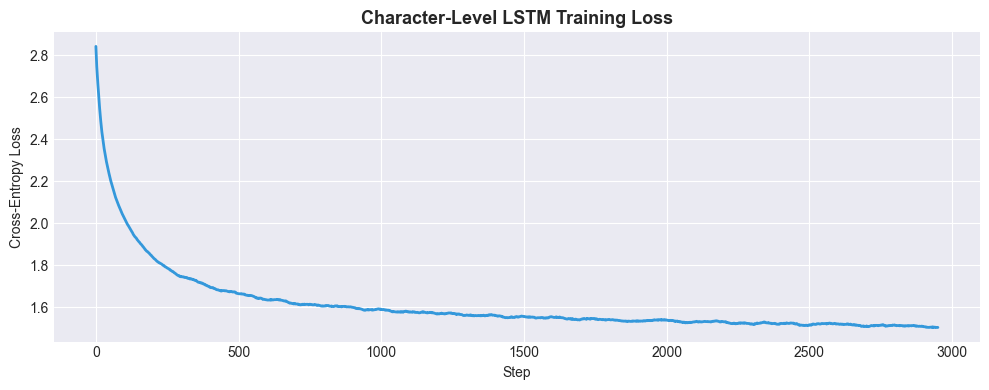

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5000)
criterion = nn.CrossEntropyLoss()

losses = []
STEPS = 3000  # Increase to 10000+ for better quality
LOG_EVERY = 500

print(f'Training for {STEPS} steps...')
t0 = time.time()

for step in range(STEPS):
    model.train()
    x, y = get_batch(data, seq_len=128, batch_size=64)
    
    logits, _ = model(x)
    loss = criterion(logits.view(-1, vocab_size), y.view(-1))
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    losses.append(loss.item())
    
    if (step + 1) % LOG_EVERY == 0:
        smooth_loss = np.mean(losses[-100:])
        elapsed = time.time() - t0
        print(f'Step {step+1:5d} | Loss: {smooth_loss:.4f} | Time: {elapsed:.0f}s')
        print('Sample:', model.generate('HAMLET:\n', 120, temperature=0.7))
        print()

# Plot loss
plt.figure(figsize=(10, 4))
window = 50
smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
plt.plot(smoothed, '#3498db', linewidth=2)
plt.xlabel('Step'); plt.ylabel('Cross-Entropy Loss')
plt.title('Character-Level LSTM Training Loss', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [10]:
# === Generate text at different temperatures ===
print('=== Temperature Comparison ===')
for temp in [0.3, 0.7, 1.0, 1.5]:
    print(f'\n--- Temperature = {temp} ---')
    print(model.generate('KING:\n', length=200, temperature=temp))
    print()

=== Temperature Comparison ===

--- Temperature = 0.3 ---
KING:
KING RICHARD II:
What is the content to my mother and the country
That my son to him to my life to be so with the hands,
And the strange of the peace to him to the prince and so should be so well have


--- Temperature = 0.7 ---
KING:
XATISTA:
No far he do would be worn to with him, if my duke weak your father.
In heart all me he and still would in see the dear:
Thou art to slander for enemain on them for the queen in him.

ANGELO:


--- Temperature = 1.0 ---
KING:
AUTOLYCUS:
How the was draws too to-most wrenser;
Fave the bloodly our will dies with
I in day, which went unto the world.
He do your lage, spreld the bitter!

Forder:
How chassiping set of yat'st, si


--- Temperature = 1.5 ---
KING:
KRRIND:
Murder!
This fondfel-chorties! ever at herself mar dothris:
Viprope,' and not?  vays I have laiving.

Nurse:
They! man: and besseave, at he: and uf as your-gray.
:
Lad curse me them, he dad'sg



## Part 4: Visualize What the LSTM Is Tracking

We can inspect the forget gate activations to see **what the LSTM remembers vs forgets** as it reads text.

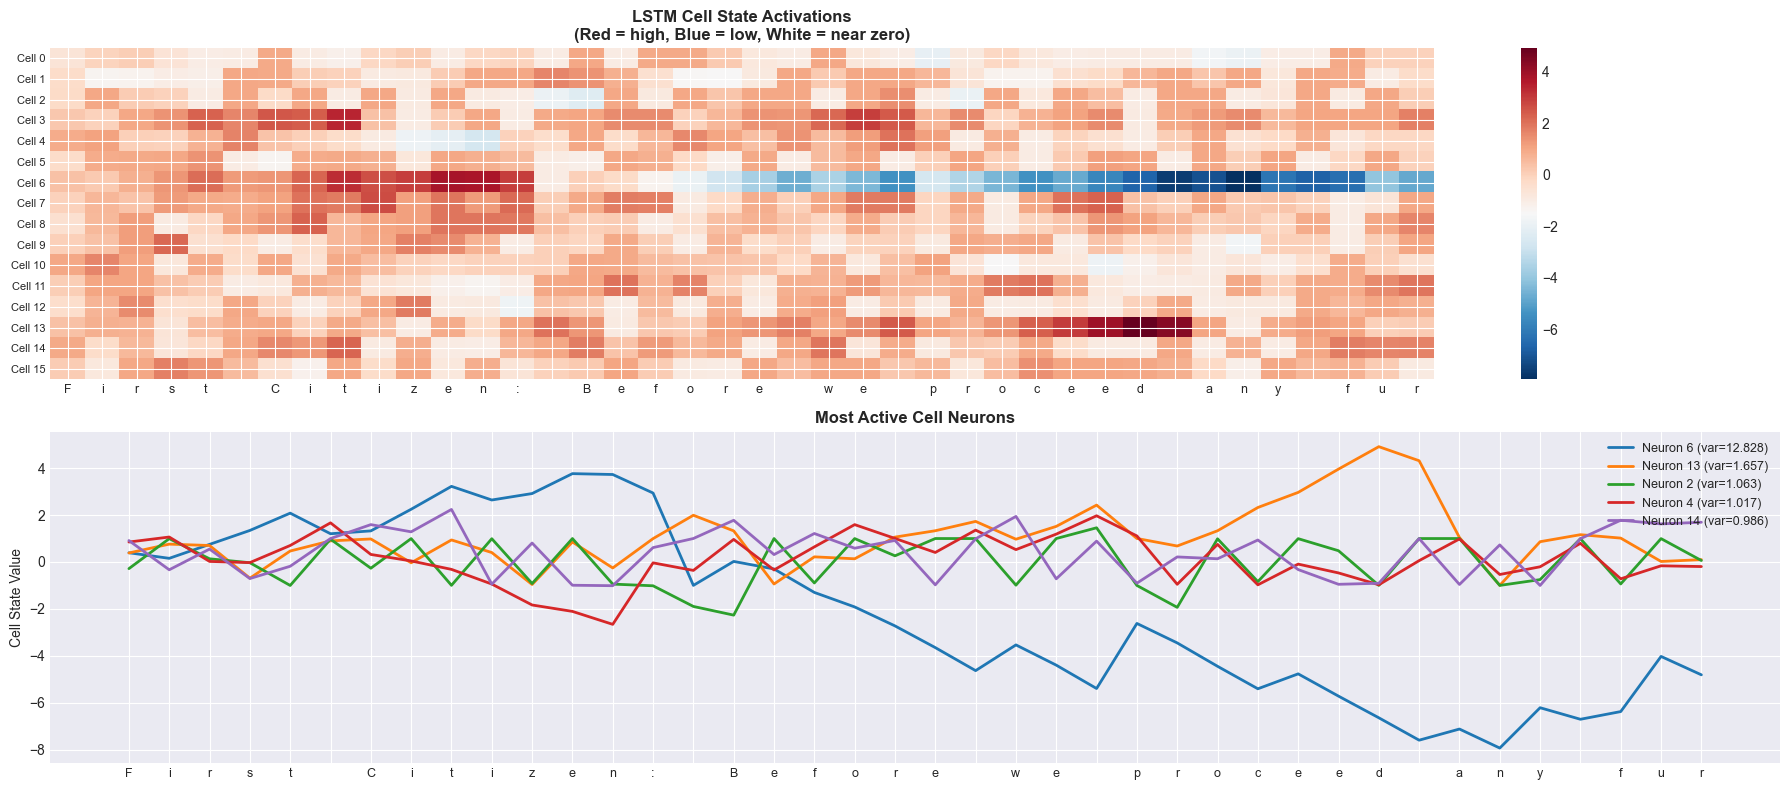

In [11]:
def visualize_gates(model, text_sample, max_neurons=20):
    """Visualize forget gate activations over time."""
    model.eval()
    
    chars = [char2idx.get(c, 0) for c in text_sample]
    x = torch.tensor(chars, dtype=torch.long).unsqueeze(0).to(device)
    
    # Hook into first LSTM layer's forget gate
    forget_gates = []
    cell_states = []
    
    h = torch.zeros(model.num_layers, 1, model.hidden_size).to(device)
    c = torch.zeros(model.num_layers, 1, model.hidden_size).to(device)
    
    with torch.no_grad():
        for t in range(len(chars)):
            emb = model.embed(x[:, t:t+1])
            _, (h, c) = model.lstm(emb, (h, c))
            
            # Extract forget gate of layer 0 via manual computation
            combined = torch.cat([h[0], emb[:, 0, :]], dim=1)
            # The LSTM stores weights differently, we'll use cell state as proxy
            cell_states.append(c[0, 0, :max_neurons].cpu().numpy())
    
    cell_states = np.array(cell_states)  # (seq_len, neurons)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 8))
    
    # Cell state heatmap
    im = ax1.imshow(cell_states.T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
    ax1.set_yticks(range(max_neurons))
    ax1.set_yticklabels([f'Cell {i}' for i in range(max_neurons)], fontsize=8)
    ax1.set_xticks(range(len(text_sample)))
    ax1.set_xticklabels(list(text_sample), fontsize=9)
    ax1.set_title('LSTM Cell State Activations\n(Red = high, Blue = low, White = near zero)', fontweight='bold')
    plt.colorbar(im, ax=ax1)
    
    # Variance of cell state — neurons with high variance are "active"
    cell_var = cell_states.var(axis=0)
    sorted_neurons = np.argsort(cell_var)[::-1][:5]
    for n in sorted_neurons:
        ax2.plot(cell_states[:, n], linewidth=2, label=f'Neuron {n} (var={cell_var[n]:.3f})')
    ax2.set_xticks(range(len(text_sample)))
    ax2.set_xticklabels(list(text_sample), fontsize=9)
    ax2.set_title('Most Active Cell Neurons', fontweight='bold')
    ax2.legend(fontsize=9, loc='upper right')
    ax2.set_ylabel('Cell State Value')
    
    plt.tight_layout()
    plt.show()

sample_text = 'First Citizen:\nBefore we proceed any further, hear me speak.'
visualize_gates(model, sample_text[:40], max_neurons=16)

## Exercises

### Exercise A — Vanilla RNN vs LSTM Memorization Test
Design an experiment to show LSTM's advantage over RNN on long-range dependencies:
1. Generate sequences like: `AXXXXXXXXB` where X can be anything, and the network must predict that `B` follows when it sees `A` at position 0 (even when separated by 50+ steps)
2. Train both RNN and LSTM. Plot accuracy vs sequence length.
3. At what length does the RNN start failing?

### Exercise B — Implement GRU from Scratch
GRU (Gated Recurrent Unit) simplifies LSTM with only 2 gates:
$$z_t = \sigma(W_z [h_{t-1}, x_t])$$ (update gate)
$$r_t = \sigma(W_r [h_{t-1}, x_t])$$ (reset gate)
$$\tilde{h}_t = \tanh(W_h [r_t \odot h_{t-1}, x_t])$$
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

Implement a `GRUCell` class and verify it matches `nn.GRUCell`.

### Exercise C — Bidirectional LSTM for Sentiment
Bidirectional LSTMs read the sequence both forward and backward. This is powerful for tasks where future context matters. Implement a BiLSTM text classifier:
1. Use the SST-2 or IMDb dataset
2. Compare accuracy: Unidirectional LSTM vs Bidirectional LSTM
3. Visualize attention weights to see which words the model focuses on

### Discussion Questions
1. Look at the generated text at temperature=0.3 vs 1.5. What's the tradeoff? When would each be appropriate?
2. Why do we use `clip_grad_norm_` during training? What happens if you remove it?
3. The forget gate is initialized with a bias of +1 in PyTorch (Jozefowicz et al., 2015). Why? What would happen with a bias of -1?